# __scPortrait workflow with DAPI Segmentation method__

To use the segmentation workflow from scPortrait, the input file saved in `.ome.tif` image format (retains no segmentation information from xenium onboard analysis) was used for the scPortrait pipeline.

In [1]:
# check the shape and dtype of the tif file
import tifffile

tif_file_path = "../data/processed/breast-cancer-rep1-10x-xenium-bundle_cropped_morphology_focus_rescaled.ome.tif"

img = tifffile.imread(tif_file_path)

y, x = img.shape

print(f"Image shape: {y} x {x} pixels")
print(img.dtype)

Image shape: 4500 x 4000 pixels
uint16


## scPortrait Project Structure (Initialization)

In [19]:
import os
import matplotlib.pyplot as plt
import numpy as np

from scportrait.pipeline.segmentation.workflows import DAPISegmentation # Standard Segmentation workflow for DAPI-stained (nuclear stained) images
from scportrait.pipeline.featurization import CellFeaturizer
from scportrait.pipeline.extraction import HDF5CellExtraction
from scportrait.pipeline.project import Project

import yaml
from IPython.display import Markdown

In [3]:
# Generate the project structure for cropped dataset from 01_prepare_xenium_data.ipynb

project_location = "../data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project"
config_file = "../configs/dapi_segmentation_config.yml"
project = Project(
    os.path.abspath(project_location),
    config_path=config_file,
    overwrite=True,
    debug=True,
    segmentation_f=DAPISegmentation,
    extraction_f=HDF5CellExtraction,
    featurization_f=CellFeaturizer
)

Updating project config file.
[27/07/2026 12:45:27] Loading config from /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/config.yml


/tmp/ipykernel_3344531/1672235315.py:5: UserWarning: There is already a directory in the location path
  project = Project(


[27/07/2026 12:45:27] No cache directory specified in config using current working directory /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks.
[27/07/2026 12:45:27] Compression algorithm for extracted single-cell images: lzf
[27/07/2026 12:45:27] No cache directory specified in config using current working directory /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks.


In [4]:
# Import the cropped Xenium dataset into the project structure

tif_file_path = "../data/processed/breast-cancer-rep1-10x-xenium-bundle_cropped_morphology_focus_rescaled.ome.tif"

project.load_input_from_tif_files(file_paths = [tif_file_path], 
                                  channel_names=["DAPI"],
                                  crop=[(0, y), (0, x)],
                                  overwrite=True)

[13/07/2026 11:31:09] Output location /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/scportrait.sdata already exists. Overwriting.
[13/07/2026 11:31:09] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/Project_jgudryao for Project
[13/07/2026 11:31:11] Image input_image written to sdata object.
[13/07/2026 11:31:11] Cleaned up temporary directory at <TemporaryDirectory '/scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/Project_jgudryao'>


In [5]:
project.print_project_status()

[13/07/2026 11:31:14] Current Project Status:
[13/07/2026 11:31:14] --------------------------------
[13/07/2026 11:31:14] Input Image in sdata: True
[13/07/2026 11:31:14] Nucleus Segmentation in sdata: False
[13/07/2026 11:31:14] Cytosol Segmentation in sdata: False
[13/07/2026 11:31:14] Nucleus Centers in sdata: False
[13/07/2026 11:31:14] Cytosol Centers in sdata: False
[13/07/2026 11:31:14] Extracted single-cell images saved to file: True
[13/07/2026 11:31:14] --------------------------------


In [6]:
# Inspect the project object
project.sdata

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/scportrait.sdata
└── Images
      └── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images)

In [7]:
project.input_image

<xarray.DataArray 'image' (c: 1, y: 4500, x: 4000)> Size: 36MB
dask.array<from-zarr, shape=(1, 4500, 4000), dtype=uint16, chunksize=(1, 256, 256), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U4 16B 'DAPI'
  * y        (y) float64 36kB 0.5 1.5 2.5 3.5 ... 4.498e+03 4.498e+03 4.5e+03
  * x        (x) float64 32kB 0.5 1.5 2.5 3.5 ... 3.998e+03 3.998e+03 4e+03
Attributes:
    transform:  {'global': Identity }

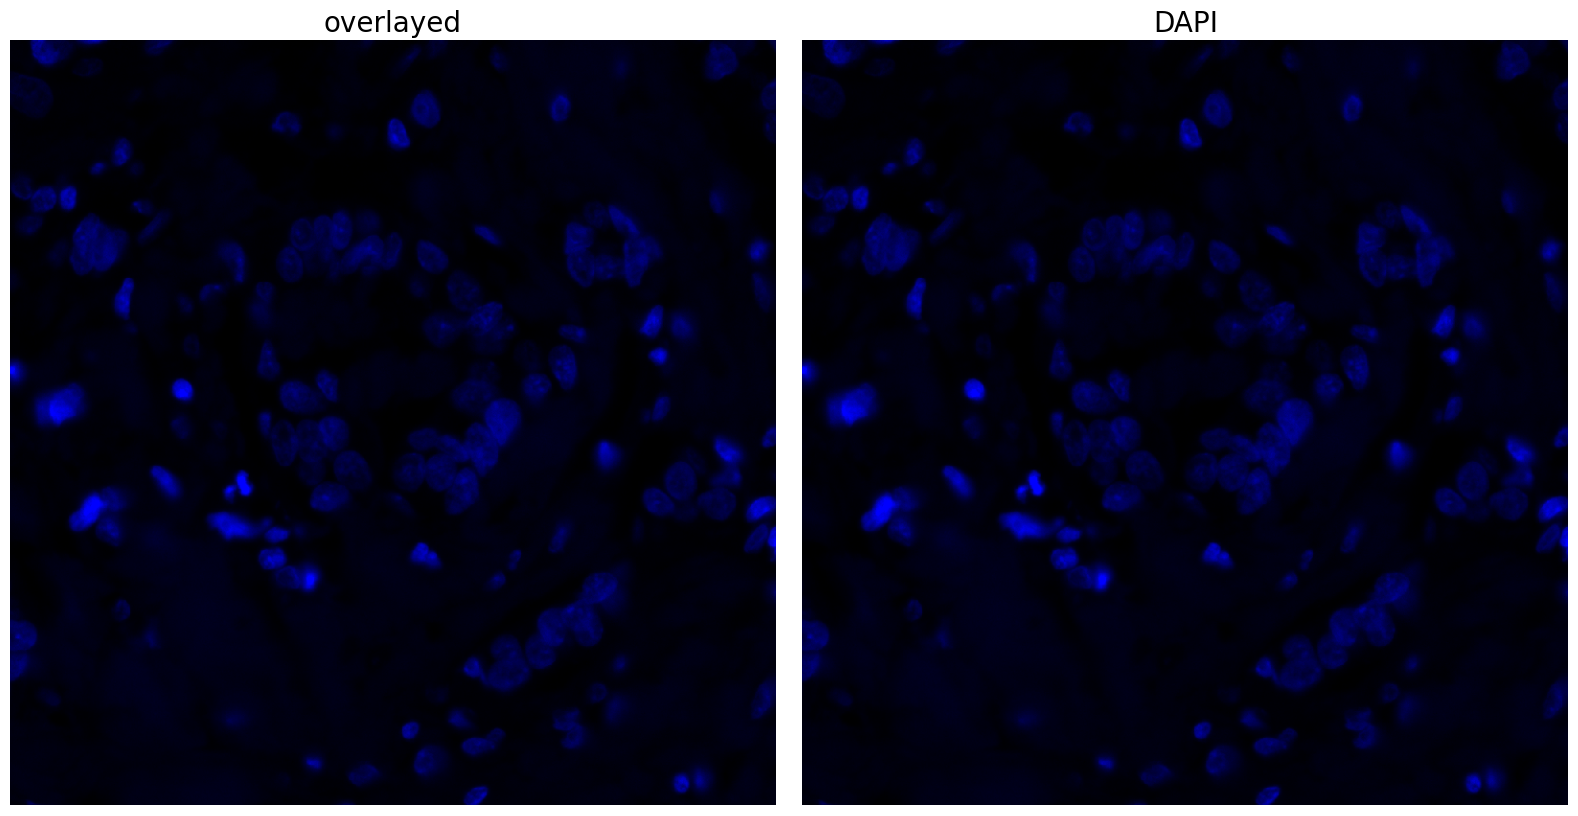

In [8]:
project.plot_input_image()

## Segmentation - DAPI

In [9]:
display(Markdown(f"```yaml\n{yaml.dump(project.segmentation_f.config, default_flow_style=False)}\n```"))

```yaml
cache: /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks
chunk_size: 50
lower_quantile_normalization: 0.001
median_filter_size: 2
nucleus_segmentation:
  contact_filter: 0.3
  dilation: 0
  lower_quantile_normalization: 0.01
  max_size: 5000
  median_block: 31
  median_step: 4
  min_distance: 5
  min_size: 150
  peak_footprint: 3
  speckle_kernel: 9
  threshold: 0.1
  upper_quantile_normalization: 0.99
upper_quantile_normalization: 0.999

```

In [10]:
print(project.input_image.shape)
print(project.input_image.dtype)

(1, 4500, 4000)
uint16


In [11]:
print(project.segmentation_f.debug)
project.segmentation_f.debug = False # Turn off debug mode for segmentation to avoid the segmentation pipeline from failing

True


### Why `segmentation_f.debug` is turned off?

scPortrait segmentation itself works on this single-channel DAPI input, but the debug plotting branch fails when `debug=True` because Matplotlib returns a single `Axes` object for a 1 x 1 subplot layout. The scPortrait code then tries to index that object like an array, which raises:

`TypeError: 'Axes' object is not subscriptable`

For that reason, `project.segmentation_f.debug` is set to `False` here, and the DAPI image is plotted separately with a simple grayscale `imshow` call.

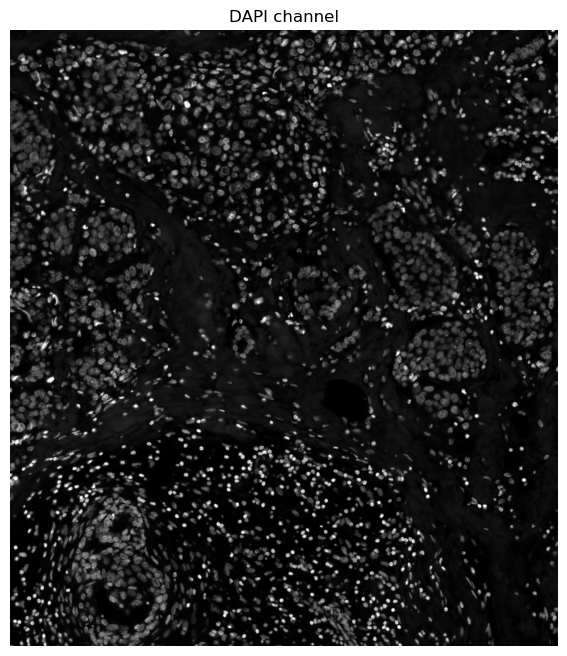

In [12]:
# Single-channel plotting: plot the 2D DAPI image directly with a grayscale colormap
dapi_img = project.input_image[0].data.compute()

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(dapi_img, cmap="gray")
ax.set_title("DAPI channel")
ax.axis("off")
plt.show()

In [13]:
# Segmentation
project.segment()

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/site-packages/scportrait/pipeline/_utils/segmentation.py:96: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  image_mask_clean = binary_erosion(image_mask, footprint=disk(speckle_kernel))


[13/07/2026 11:32:17] Segmentation seg_all_nucleus written to sdata object.
[13/07/2026 11:32:18] Points centers_seg_all_nucleus written to sdata object.


In [14]:
# SpatialData object after segmentation
project.sdata

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/scportrait.sdata
├── Images
│     └── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
├── Labels
│     └── 'seg_all_nucleus': DataTree[yx] (4500, 4000), (2250, 2000), (562, 500), (70, 62)
└── Points
      └── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images), seg_all_nucleus (Labels), centers_seg_all_nucleus (Points)

In [15]:
# Compute the number of segmented nuclei
from skimage.measure import regionprops

nuc = project.sdata.labels["seg_all_nucleus"]["scale0"]["image"].data.compute()

print(len(regionprops(nuc)))

4117


In [16]:
# Compute the segmented nuclei area statistics
areas = [r.area for r in regionprops(nuc)]

print("Count:", len(areas))
print("Median:", np.median(areas))
print("5th percentile:", np.percentile(areas, 5))
print("95th percentile:", np.percentile(areas, 95))

Count: 4117
Median: 568.0
5th percentile: 207.0
95th percentile: 1490.1999999999998


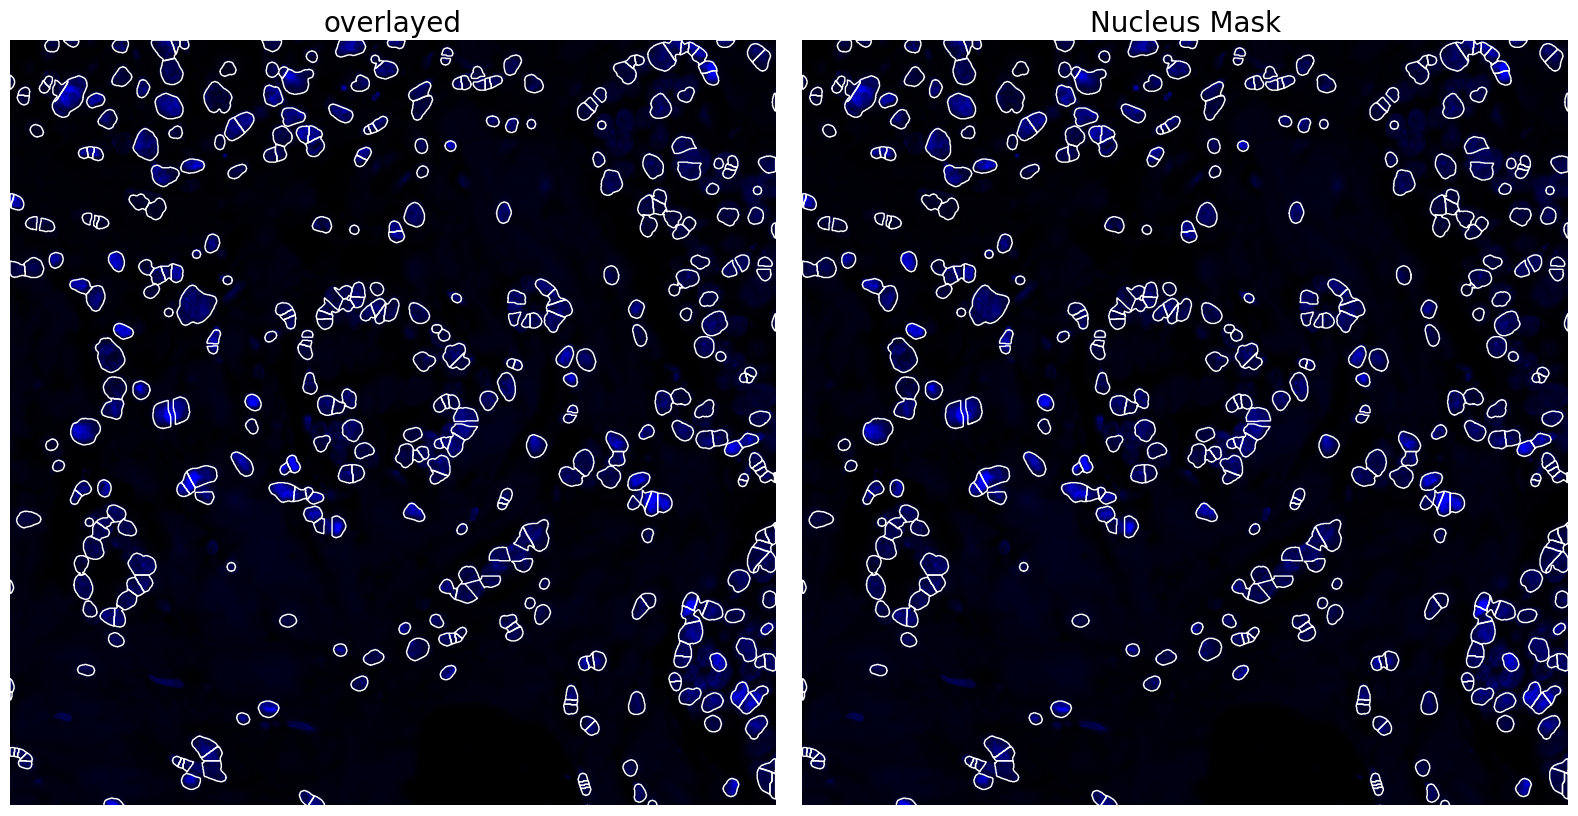

In [17]:
project.plot_segmentation_masks()

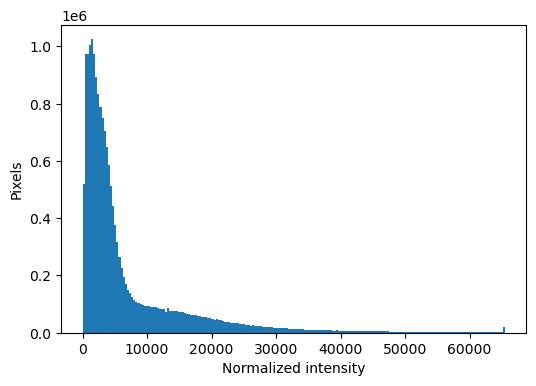

In [18]:
# Plot the histogram of pixel intensities in the DAPI channel
img = project.input_image[0].data.compute() # turns the dask array into a numpy array

plt.figure(figsize=(6,4))
plt.hist(img.ravel(), bins=200)
plt.xlabel("Normalized intensity")
plt.ylabel("Pixels")
plt.show()

## Single-cell extraction

In [19]:
# Extracting single cell images (using the nucleus segmentation masks)
display(Markdown(f"```yaml\n{yaml.dump(project.extraction_f.config, default_flow_style=False)}\n```"))

```yaml
cache: .
compression: true
image_size: 64
normalize_output: false
segmentation_mask: seg_all_nucleus
threads: 8

```

In [20]:
project.extract()

[13/07/2026 11:32:36] Initialized temporary directory at ./HDF5CellExtraction_9wdy8lu1 for HDF5CellExtraction
[13/07/2026 11:32:36] Created new directory for extraction results: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data
[13/07/2026 11:32:36] Setup output folder at /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data
[13/07/2026 11:32:36] Found 1 segmentation masks for the given key in the sdata object. Will be extracting single-cell images based on these masks: ['seg_all_nucleus']
[13/07/2026 11:32:36] Using seg_all_nucleus as the main segmentation mask to determine cell centers.
[13/07/2026 11:32:36] A total of 54 cells were too close to the image border to be extracted. Their cell_ids were saved to file /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentatio

Extracting cell batches:   0%|          | 0/8 [00:00<?, ?it/s]

[13/07/2026 11:32:42] Finished extraction in 5.22 seconds (777.77 cells / second)
[13/07/2026 11:32:43] Benchmarking times saved to file.
[13/07/2026 11:32:43] Cleaned up temporary directory at ./HDF5CellExtraction_9wdy8lu1


In [21]:
# Show the created AnnData object after single cell image extraction
project.h5sc

AnnData object with n_obs × n_vars = 4063 × 2
    obs: 'scportrait_cell_id'
    var: 'channels', 'channel_mapping'
    uns: 'single_cell_images'
    obsm: 'single_cell_images'

In [22]:
display("Single cell image dataset:", project.h5sc.obsm["single_cell_images"])
display("Metadata:", project.h5sc.uns["single_cell_images"])

'Single cell image dataset:'

<HDF5 dataset "single_cell_images": shape (4063, 2, 64, 64), type "<f2">

'Metadata:'

{'channel_mapping': array(['mask', 'image_channel'], dtype=object),
 'channel_names': array(['seg_all_nucleus', 'DAPI'], dtype=object),
 'compression': 'lzf',
 'image_size': 64,
 'n_cells': 4063,
 'n_channels': 2,
 'n_image_channels': 1,
 'n_masks': 1,
 'normalization': False,
 'normalization_range_lower': 'None',
 'normalization_range_upper': 'None'}

In [23]:
project.h5sc.obs

,scportrait_cell_id
0,1
1,2
2,3
3,4
4,5
...,...
4058,4604
4059,4605
4060,4606
4061,4607


In [24]:
project.h5sc.var

,channels,channel_mapping
0,seg_all_nucleus,mask
1,DAPI,image_channel


(2, 64, 64)


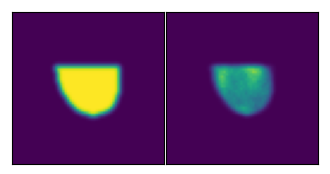

In [25]:
# Visualize the extracted single cell images for a specific cell ID
import scportrait

cell_id = 2502
image_of_cell = scportrait.tl.h5sc.get_image_with_cellid(project.h5sc, cell_id)
print(image_of_cell.shape)
fig, axs = plt.subplots(1, 1, figsize=(2 * 2, 2))
scportrait.pl.h5sc._plot_image_grid(ax=axs, images=image_of_cell, nrows=1, ncols=2)

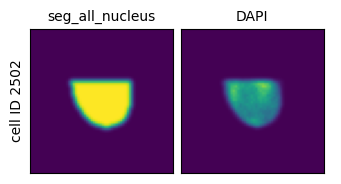

In [26]:
scportrait.pl.cell_grid(project.h5sc, cell_ids=cell_id)

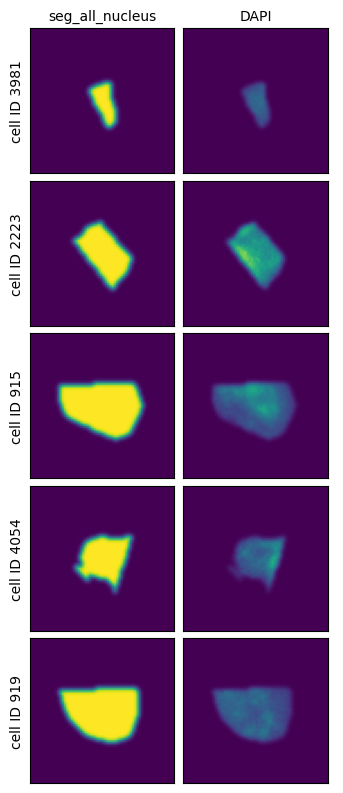

In [27]:
# Visualize the extracted single cell images for randomly selected cell IDs
project.plot_single_cell_images()


## Featurization - using CellFeaturizer

In [28]:
display(Markdown(f"```yaml\n{yaml.dump(project.featurization_f.config, default_flow_style=False)}\n```"))

```yaml
batch_size: 900
cache: /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks
dataloader_worker_number: 0
inference_device: cpu

```

In [29]:
project.featurize(overwrite = True)

Using extraction directory: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data/single_cells.h5sc
[13/07/2026 11:34:01] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_bat_ttte for CellFeaturizer
[13/07/2026 11:34:01] Started CellFeaturization of all available channels.
[13/07/2026 11:34:01] Overwrite flag is set, deleting existing directory for featurization results.
[13/07/2026 11:34:01] Created new directory for featurization results: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/featurization/complete_CellFeaturizer
[13/07/2026 11:34:01] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_wyu5bmh_ for CellFeaturizer
[13/07/2026 11:34:01] Reading data from path: /scratch/tmurugan/scportrait-spatial-omics-qc/data/i

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar

[13/07/2026 11:34:02] Table CellFeaturizer_nucleus written to sdata object.
[13/07/2026 11:34:02] GPU memory before performing cleanup: None
[13/07/2026 11:34:02] GPU memory after performing cleanup: None
[13/07/2026 11:34:03] Cleaned up temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_wyu5bmh_


In [30]:
# Examine the SpatialData object after featurization
project.sdata

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/scportrait.sdata
├── Images
│     └── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
├── Labels
│     └── 'seg_all_nucleus': DataTree[yx] (4500, 4000), (2250, 2000), (562, 500), (70, 62)
├── Points
│     └── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Tables
      └── 'CellFeaturizer_nucleus': AnnData (4063, 7)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images), seg_all_nucleus (Labels), centers_seg_all_nucleus (Points)

In [31]:
# View the extracted features for the segmented nuclei
results = project.sdata["CellFeaturizer_nucleus"].to_df()
print(results.head())

   nucleus_area  DAPI_mean_nucleus  DAPI_median_nucleus  DAPI_quant75_nucleus  \
0        3583.0           0.397427             0.420166              0.543457   
1        3389.0           0.288288             0.216797              0.384521   
2        3923.0           0.313462             0.338623              0.392822   
3        3821.0           0.269441             0.293701              0.375488   
4        2880.0           0.264948             0.261719              0.409485   

   DAPI_quant25_nucleus  DAPI_summed_intensity_nucleus  \
0              0.305908                    1423.980469   
1              0.148682                     977.006653   
2              0.267822                    1229.709839   
3              0.179321                    1029.535767   
4              0.070587                     763.050232   

   DAPI_summed_intensity_area_normalized_nucleus  
0                                       0.397427  
1                                       0.288288  
2          

In [32]:
results["nucleus_area"].describe()

count    4063.000000
mean     1182.605225
std       545.128601
min       362.000000
25%       774.000000
50%      1074.000000
75%      1453.000000
max      3923.000000
Name: nucleus_area, dtype: float64

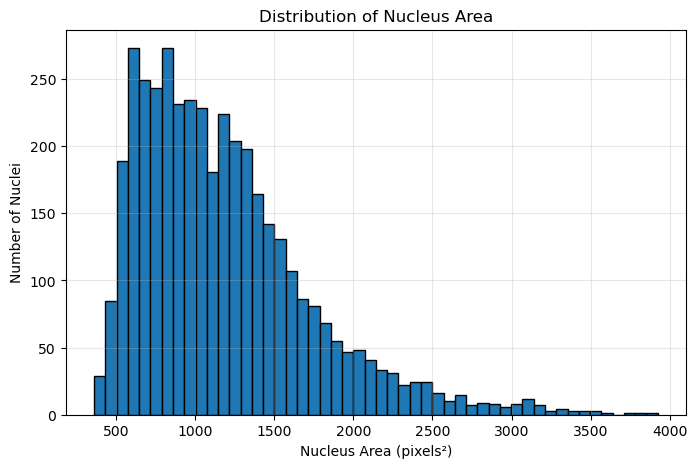

In [33]:
# Plot the histogram of nucleus area
plt.figure(figsize=(8, 5))

plt.hist(results["nucleus_area"], bins=50, edgecolor="black")

plt.title("Distribution of Nucleus Area")
plt.xlabel("Nucleus Area (pixels²)")
plt.ylabel("Number of Nuclei")

plt.grid(alpha=0.3)
plt.show()

## Clustering (based on nuclei features from `CellFeaturizer`)

In [34]:
# Keep only numeric features
X = results.select_dtypes(include=np.number)

print(X.shape)
X.head()

(4063, 7)


,nucleus_area,DAPI_mean_nucleus,DAPI_median_nucleus,DAPI_quant75_nucleus,DAPI_quant25_nucleus,DAPI_summed_intensity_nucleus,DAPI_summed_intensity_area_normalized_nucleus
0,3583.0,0.397427,0.420166,0.543457,0.305908,1423.980469,0.397427
1,3389.0,0.288288,0.216797,0.384521,0.148682,977.006653,0.288288
2,3923.0,0.313462,0.338623,0.392822,0.267822,1229.709839,0.313462
3,3821.0,0.269441,0.293701,0.375488,0.179321,1029.535767,0.269441
4,2880.0,0.264948,0.261719,0.409485,0.070587,763.050232,0.264948


In [35]:
# Create an AnnData object for the extracted features
import anndata as ad

adata_feat = ad.AnnData(X)
adata_feat.obs_names = results.index.astype(str)

In [36]:
# Perform dimensional reduction and clustering based on the extracted features
import scanpy as sc
from sklearn.preprocessing import StandardScaler

adata_feat.X = StandardScaler().fit_transform(adata_feat.X)

sc.tl.pca(adata_feat)
sc.pp.neighbors(adata_feat, n_neighbors=15, n_pcs=20)
sc.tl.umap(adata_feat)
sc.tl.leiden(
    adata_feat,
    resolution=0.5,
    key_added="morphology_cluster_label"
)

adata_feat.obs["morphology_cluster_label"].value_counts()

/tmp/ipykernel_2330879/3374749162.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


morphology_cluster_label
0     481
1     453
2     374
3     352
4     295
5     285
6     275
7     274
8     243
9     236
10    221
11    201
12    193
13    180
Name: count, dtype: int64

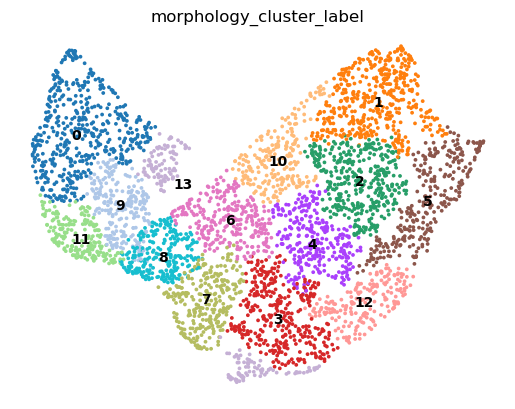

In [37]:
# Visualize the UMAP embedding colored by 'morphology_cluster_label'
sc.pl.umap(
    adata_feat,
    color="morphology_cluster_label",
    legend_loc="on data",
    frameon=False,
)

In [38]:
# Inspect the SpatialData object (to append the cluster labels to the 'tables' element of the SpatialData object)
print(project.sdata) 
print(project.sdata.tables)

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/scportrait.sdata
├── Images
│     └── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
├── Labels
│     └── 'seg_all_nucleus': DataTree[yx] (4500, 4000), (2250, 2000), (562, 500), (70, 62)
├── Points
│     └── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Tables
      └── 'CellFeaturizer_nucleus': AnnData (4063, 7)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images), seg_all_nucleus (Labels), centers_seg_all_nucleus (Points)
{'CellFeaturizer_nucleus': AnnData object with n_obs × n_vars = 4063 × 7
    obs: 'scportrait_cell_id', 'region'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'}


In [39]:
# Create a copy of the 'CellFeaturizer_nucleus' table and add the 'morphology_cluster_label' to it
feat_adata = project.sdata.tables["CellFeaturizer_nucleus"].copy()
feat_adata.obs["morphology_cluster_label"] = (
    adata_feat.obs.loc[feat_adata.obs_names, "morphology_cluster_label"].values
)

In [41]:
# Create a new SpatialData object with all the elements and the updated table and write it to a new path
from pathlib import Path
from spatialdata import SpatialData

output_path = Path("../data/results/xenium_dapi_cellfeaturizer.sdata.zarr")
output_path.parent.mkdir(parents=True, exist_ok=True)

sdata_result = SpatialData(
    images=dict(project.sdata.images),
    labels=dict(project.sdata.labels),
    points=dict(project.sdata.points),
    shapes=dict(project.sdata.shapes),
    tables={
        "CellFeaturizer_nucleus": feat_adata,
    },
)

sdata_result.write(output_path)

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar

In [ ]:
# Copy original SpatialData object
#sdata_result = copy.deepcopy(project.sdata)
#print(sdata_result)

# Add new table
#sdata_result.tables["CellFeaturizer_nucleus"] = feat_adata
#print(sdata_result)

# Write complete modified SpatialData to a new location
#sdata_result.write(output_path)

# Export the updated SpatialData object to a separate path
#project.sdata.write(output_path)

# Did not work as expected, as deepcopy missed out metadata of some elements in the original SpatialData object.

## Featurization - MLClusterClassifier

To verify the end-to-end scPortrait pipeline, the `MLClusterClassifier` was tested using the pretrained `autophagy_classifier` model included in the scPortrait library. The model was used solely to validate the classification workflow on the extracted single-cell images and not for biological interpretation of the predictions.

In [40]:
from scportrait.pipeline.featurization import MLClusterClassifier

# Update the featurization configuration to use MLClusterClassifier and the updated configuration file
project.config_path = "../configs/dapi_segmentation_config.yml"
project._get_config_file(project.config_path)
project._setup_featurization_f(MLClusterClassifier)

display(Markdown(f"```yaml\n{yaml.dump(project.featurization_f.config, default_flow_style=False)}\n```"))

Updating project config file.
[13/07/2026 11:36:47] Loading config from /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/config.yml
[13/07/2026 11:36:47] No cache directory specified in config using current working directory /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks.


```yaml
batch_size: 256
cache: /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks
channel_selection: 1
dataloader_worker_number: 0
encoders:
- forward
inference_device: cpu
label: Autophagy_15h_classifier2_1
network: autophagy_classifier

```

In [41]:
# Note that an object of the MLClusterClassifier class is created and assigned to the featurization_f attribute of the project object
print(project.featurization_f)
print(type(project.featurization_f))

<class 'scportrait.pipeline.featurization.MLClusterClassifier'>


In [42]:
project.featurize(overwrite = True)

Using extraction directory: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data/single_cells.h5sc
[13/07/2026 11:37:49] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/MLClusterClassifier_gl_3b6_m for MLClusterClassifier
[13/07/2026 11:37:49] Started MLClusterClassifier classification.
[13/07/2026 11:37:49] Overwrite flag is set, deleting existing directory for featurization results.
[13/07/2026 11:37:49] Created new directory for featurization results: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/featurization/complete_Autophagy_15h_classifier2_1
[13/07/2026 11:37:49] Model class defined as <class 'scportrait.tools.ml.plmodels.MultilabelSupervisedModel'>


Lightning automatically upgraded your loaded checkpoint from v1.5.5 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../conda_envs/env_scportrait/lib/python3.11/site-packages/scportrait/scportrait_data/vgg_autophagy_classifier/VGG2_autophagy_classifier2.1.cpkt`


[13/07/2026 11:37:50] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/MLClusterClassifier_xf2dzryp for MLClusterClassifier
[13/07/2026 11:37:50] Reading data from path: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data/single_cells.h5sc
[13/07/2026 11:37:50] Expected image size is set to (128, 128). Resizing images to this size.
[13/07/2026 11:37:50] Processing dataset with 4063 cells
[13/07/2026 11:37:50] Dataloader generated with a batchsize of 256 and 0 workers. Dataloader contains 16 entries.
[13/07/2026 11:37:50] Starting inference for model encoder forward
[13/07/2026 11:37:50] Started processing of 16 batches.
[13/07/2026 11:37:50] processing batch 0
[13/07/2026 11:37:54] processing batch 10
[13/07/2026 11:37:55] Finished processing, returning results as memmap files.


/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar

[13/07/2026 11:37:56] Table MLClusterClassifier_Autophagy_15h_classifier2_1_forward_nucleus written to sdata object.
[13/07/2026 11:37:56] Results saved to file: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/featurization/complete_Autophagy_15h_classifier2_1/inference_forward.csv
[13/07/2026 11:37:56] GPU memory before performing cleanup: None
[13/07/2026 11:37:56] GPU memory after performing cleanup: None
[13/07/2026 11:37:56] Cleaned up temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/MLClusterClassifier_xf2dzryp


In [43]:
# Inspect the SpatialData object after featurization with MLClusterClassifier
project.sdata

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/scportrait.sdata
├── Images
│     └── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
├── Labels
│     └── 'seg_all_nucleus': DataTree[yx] (4500, 4000), (2250, 2000), (562, 500), (70, 62)
├── Points
│     └── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Tables
      ├── 'CellFeaturizer_nucleus': AnnData (4063, 7)
      └── 'MLClusterClassifier_Autophagy_15h_classifier2_1_forward_nucleus': AnnData (4063, 2)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images), seg_all_nucleus (Labels), centers_seg_all_nucleus (Points)

In [44]:
# Load MLClusterClassifier AnnData and prepare results

adata = project.sdata["MLClusterClassifier_Autophagy_15h_classifier2_1_forward_nucleus"].copy()

adata.var_names = [
    "autophagy_competent_probability_class_0",
    "autophagy_deficient_probability_class_1",
]

# Convert log-probabilities (in scPortrait output for increased precision) to probabilities
adata.X = np.exp(adata.X)

In [45]:
# Create a DataFrame from the AnnData object for downstream analysis and visualization
adata.to_df().head()
results = adata.to_df()

results.insert(
    0,
    "scportrait_cell_id",
    adata.obs["scportrait_cell_id"].values,
)

results

,scportrait_cell_id,autophagy_competent_probability_class_0,autophagy_deficient_probability_class_1
0,1,2.173952e-05,0.999978
1,2,5.025334e-05,0.999950
2,3,6.334667e-05,0.999937
3,4,2.024168e-05,0.999980
4,5,3.956945e-07,1.000000
...,...,...,...
4058,4604,6.638635e-07,0.999999
4059,4605,6.122187e-07,0.999999
4060,4606,6.164346e-07,0.999999
4061,4607,1.266805e-07,1.000000


In [47]:
# Save the results to a CSV file in the results directory
from pathlib import Path

results_dir = Path("../data/results")
results_dir.mkdir(parents=True, exist_ok=True)

results.to_csv(
    results_dir / "mlclusterclassifier_autophagy_predictions_for_dapi_segmentation.csv",
    index=False,
)

In [51]:
# Add the edited ML classifier table to existing SpatialData

from spatialdata import SpatialData

output_path = "../data/results/xenium_dapi_cellfeaturizer.sdata.zarr"

# Open the existing SpatialData
sdata = SpatialData.read(output_path)

# Add the new table in memory
sdata.tables[
    "MLClusterClassifier_Autophagy_15h_classifier2_1_forward_nucleus"
] = adata

# Verify that the new table has been added to the SpatialData object before writing to disk
print(sdata.tables.keys())

dict_keys(['CellFeaturizer_nucleus', 'MLClusterClassifier_Autophagy_15h_classifier2_1_forward_nucleus'])


In [52]:
# Write only the new table to disk
sdata.write_element(
    "MLClusterClassifier_Autophagy_15h_classifier2_1_forward_nucleus",
    overwrite=True,
)

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar

## Featurization - ConvNeXtFeaturizer

In [4]:
from scportrait.pipeline.featurization import ConvNeXtFeaturizer

# Update the featurization configuration to use ConvNeXtFeaturizer and the updated configuration file
project.config_path = "../configs/dapi_segmentation_config.yml"
project._get_config_file(project.config_path)
project._setup_featurization_f(ConvNeXtFeaturizer)

display(Markdown(f"```yaml\n{yaml.dump(project.featurization_f.config, default_flow_style=False)}\n```"))

Updating project config file.
[27/07/2026 12:45:40] Loading config from /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/config.yml
[27/07/2026 12:45:40] No cache directory specified in config using current working directory /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks.


```yaml
batch_size: 16
cache: /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks
channel_selection: 1
dataloader_worker_number: 0
inference_device: cpu
label: ConvNeXtFeaturizer

```

In [5]:
# Note that an object of the ConvNeXtFeaturizer class is created and assigned to the featurization_f attribute of the project object
print(project.featurization_f)
print(type(project.featurization_f))

<class 'scportrait.pipeline.featurization.ConvNeXtFeaturizer'>


In [6]:
project.featurize(overwrite = True)

Using extraction directory: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data/single_cells.h5sc
[27/07/2026 12:46:23] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/ConvNeXtFeaturizer_icy96js_ for ConvNeXtFeaturizer
[27/07/2026 12:46:23] Created new directory for featurization results: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/featurization/complete_ConvNeXtFeaturizer_Ch1


config.json:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.57GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

[transformers] ConvNextModel LOAD REPORT from: facebook/convnext-xlarge-224-22k
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[27/07/2026 12:46:37] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/ConvNeXtFeaturizer_390a786z for ConvNeXtFeaturizer
[27/07/2026 12:46:37] Reading data from path: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data/single_cells.h5sc
[27/07/2026 12:46:37] Processing dataset with 4063 cells
[27/07/2026 12:46:37] Dataloader generated with a batchsize of 16 and 0 workers. Dataloader contains 254 entries.
[27/07/2026 12:46:37] Started processing of 254 batches.
[27/07/2026 12:46:59] processing batch 0
[27/07/2026 12:47:26] processing batch 10
[27/07/2026 12:48:03] processing batch 20
[27/07/2026 12:48:41] processing batch 30
[27/07/2026 12:49:16] processing batch 40
[27/07/2026 12:50:03] processing batch 50
[27/07/2026 12:50:53] processing batch 60
[27/07/2026 12:51:41] processing batch 70
[27/07/2026 12:52:27] processing batch 80
[27/07/2026 12:53:11] process

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar

[27/07/2026 13:05:05] Table ConvNeXtFeaturizer_Ch1_nucleus written to sdata object.
[27/07/2026 13:05:05] GPU memory before performing cleanup: None
[27/07/2026 13:05:06] GPU memory after performing cleanup: None
[27/07/2026 13:05:06] Cleaned up temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/ConvNeXtFeaturizer_390a786z


In [7]:
# Inspect the SpatialData object after featurization with ConvNeXtFeaturizer
project.sdata

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/scportrait.sdata
├── Images
│     └── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
├── Labels
│     └── 'seg_all_nucleus': DataTree[yx] (4500, 4000), (2250, 2000), (562, 500), (70, 62)
├── Points
│     └── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Tables
      ├── 'CellFeaturizer_nucleus': AnnData (4063, 7)
      ├── 'ConvNeXtFeaturizer_Ch1_nucleus': AnnData (4063, 2048)
      └── 'MLClusterClassifier_Autophagy_15h_classifier2_1_forward_nucleus': AnnData (4063, 2)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images), seg_all_nucleus (Labels), centers_seg_all_nucleus (Points)

In [14]:
project.sdata.tables["ConvNeXtFeaturizer_Ch1_nucleus"].X.shape

(4063, 2048)

In [15]:
project.sdata.tables["ConvNeXtFeaturizer_Ch1_nucleus"].X

array([[ 0.3084148 , -0.00057372,  0.00142453, ..., -0.08472948,
        -0.0021193 ,  0.30156952],
       [ 0.4611558 , -0.00055902,  0.00120829, ...,  0.18061951,
        -0.3327312 ,  0.21919304],
       [ 0.3280257 , -0.00066383,  0.00104062, ..., -0.23418316,
        -0.11173383,  0.02936685],
       ...,
       [ 0.23064941, -0.00065872,  0.00076174, ...,  0.03661422,
        -0.1258105 ,  0.15029104],
       [ 0.11391298, -0.00067674,  0.00104422, ..., -0.06957006,
        -0.01447331,  0.12304241],
       [ 0.35416606, -0.00064141,  0.00076393, ...,  0.0036461 ,
        -0.17070906,  0.12634595]], dtype=float32)

In [20]:
# Load ConvNeXtFeaturizer AnnData

adata = project.sdata["ConvNeXtFeaturizer_Ch1_nucleus"].copy()

In [21]:
# Add the edited ConvNeXtFeaturizer table to existing SpatialData

from spatialdata import SpatialData

output_path = "../data/results/xenium_dapi_cellfeaturizer.sdata.zarr"

# Open the existing SpatialData
sdata = SpatialData.read(output_path)

# Add the new table in memory
sdata.tables[
    "ConvNeXtFeaturizer_Ch1_nucleus"
] = adata

# Verify that the new table has been added to the SpatialData object before writing to disk
print(sdata.tables.keys())

dict_keys(['CellFeaturizer_nucleus', 'MLClusterClassifier_Autophagy_15h_classifier2_1_forward_nucleus', 'ViT-MAE_pretrained_PooledEmbeddings', 'ConvNeXtFeaturizer_Ch1_nucleus'])


In [22]:
# Write only the new table to disk
sdata.write_element(
    "ConvNeXtFeaturizer_Ch1_nucleus",
    overwrite=True,
)

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar